# RAG in context

RAG gets a language model to answer questions from documents it was never trained on, by
finding the right passages and pasting them into the prompt. Most of what makes the
searching work predates the models, so this connects it back to ideas that have been
around a lot longer. This is a refresher, filling in gaps along the way.

Everything here runs on a laptop with no account and no API key. Two small models download
once and then it works offline.

## The problem

Somewhere in a company wiki, a support archive, or a codebase nobody has read end to end is
the paragraph answering your question. Two things are in the way.

**Keyword search makes you guess the author's words.** Search "wipe the database" and miss
the file that says `make reset`.

**A language model has never seen those documents.** Pasting them all into the prompt is the
obvious fix, and it stops working once they outgrow the **context window**, the fixed budget
of text a model can be given at once.

So: find the few paragraphs most likely to answer the question, and paste only those. That is
**retrieval-augmented generation**, and the finding step is the R, where nearly all the
engineering lives.

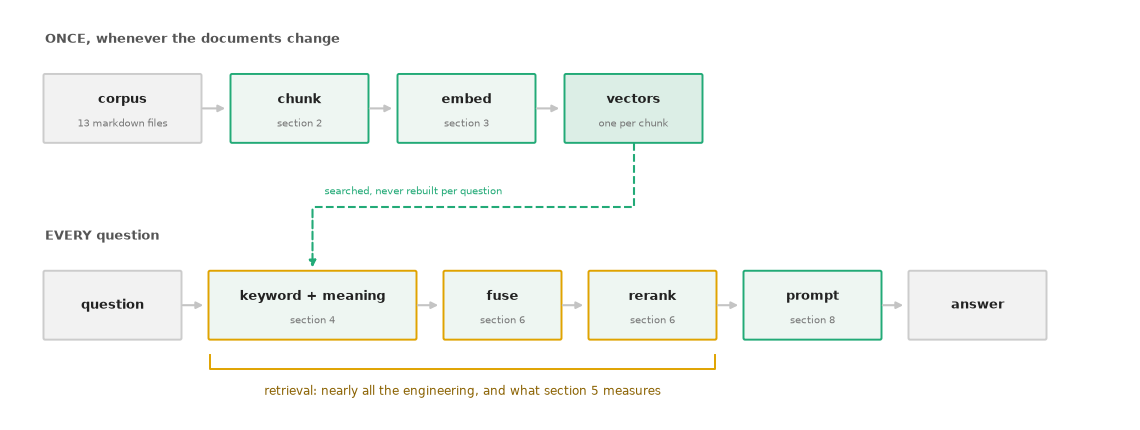

In [1]:
import figures

figures.pipeline()

Two loops: the top row runs once, whenever the documents change, the bottom row for every
question asked.

*In production:* you would call a framework instead. This is LlamaIndex, from its starter
guide, and it is the whole pipeline:

```
from llama_index.core import VectorStoreIndex, SimpleDirectoryReader

documents = SimpleDirectoryReader("corpus").load_data()
index     = VectorStoreIndex.from_documents(documents)   # chunks, embeds, stores
answer    = index.as_query_engine().query(question)      # retrieves, ranks, prompts, generates
```

LlamaIndex because it leads on ingestion and retrieval and gets there in three lines.
LangChain leads on chaining and agents, and section 2 borrows its splitter. Mixing them is
ordinary.

The last two lines are this whole notebook. **Sections 2 to 7 are the R, and section 8 alone
is the G**, which is the ratio in miniature: retrieval is where the engineering is and
generation is one prompt. Every box above holds a decision the framework makes for you, and
sections 5 and 7 measure those decisions, which no call does. Nothing below runs a framework:
each section imports one small library, or none, and shows what it did.

The strip under each heading is that diagram again, same names and phases. Orange is whatever
the section is about: a lit box, a bracket over the boxes some choice acts on, or a loop for
the scoring cycle. Green dashed is always the vectors, computed once and searched every
time.

## 1. Where this sits in the ML you already know

**RAG involves no training.** It is an architecture: search, then paste into a prompt. That
is why it caught on, since it gives a model your documents without the cost and risk of
fine-tuning. The rough rule is that fine-tuning teaches new *behaviour* and retrieval gives
new *facts*. Plenty of people reaching for the first want the second.

**The pieces sit in familiar categories.** Keyword search does not learn at all; it is
arithmetic over word counts, and the version here dates to the 1990s. The embedding model is
deep learning, pretrained then tuned on sentence pairs. The reranker in section 6 is ordinary
supervised learning, trained on labelled query and document pairs.

**And the core operation is one you have already used.** Represent things as vectors, compare
them with a cosine. That is decades old, and what changed is where the numbers come from.

## 2. Cutting documents into chunks

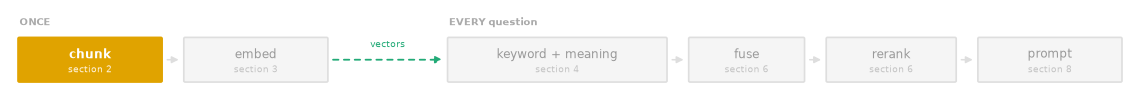

In [2]:
figures.locate("chunk")

First box on the top row. Retrieval returns passages rather than whole files, because a file
is too big for the prompt and too broad to match a question. Cut too small and a piece loses
its context, too large and it covers several topics at once.

`RecursiveCharacterTextSplitter` does the cutting, and it is the splitter most RAG code you
meet uses. It ships in `langchain-text-splitters`, installed without the framework.
*Recursive character* names the algorithm: try separators in order, coarsest first. Blank
lines, then single lines, then spaces, then anywhere. So it breaks at a paragraph boundary
when it can and mid-word only when it must.

In [3]:
import re, pathlib, numpy as np, figures
from collections import Counter
from langchain_text_splitters import RecursiveCharacterTextSplitter

CORPUS = pathlib.Path("corpus")
# Relative paths, so say this clearly rather than failing later with an empty corpus.
assert CORPUS.is_dir(), f"no corpus/ found from {pathlib.Path.cwd()} - run from the repo root"

def build_chunks(chunk_size=400, overlap=80):
    sp = RecursiveCharacterTextSplitter(chunk_size=chunk_size, chunk_overlap=overlap,
                                        separators=["\n\n", "\n", " ", ""])
    return [{"repo": p.name.split("__")[0], "file": p.name, "text": t}
            for p in sorted(CORPUS.glob("*.md")) for t in sp.split_text(p.read_text())]

chunks = build_chunks()
print(f"{len(chunks)} chunks from {len(list(CORPUS.glob('*.md')))} files, "
      f"median {int(np.median([len(c['text']) for c in chunks]))} chars")

324 chunks from 13 files, median 316 chars


The `chunk_overlap=80` repeats the last 80 characters of each piece at the start of the
next. Section 7 comes back to what the size costs.

In [4]:
i = next(k for k, c in enumerate(chunks) if "Adoption peaked near" in c["text"])
print(f"end of chunk {i}:    ...{chunks[i]['text'][-88:]}")
print(f"start of chunk {i+1}:  {chunks[i+1]['text'][:88]}...")

end of chunk 140:    ...dataset, or
data that is really a graph. Not for a longer list. Adoption peaked near 40%
start of chunk 141:  data that is really a graph. Not for a longer list. Adoption peaked near 40%
around 2021...


The first piece stops mid-sentence at the size limit. The second opens with that same
sentence intact, which is the overlap doing its job.

## 3. Text as vectors

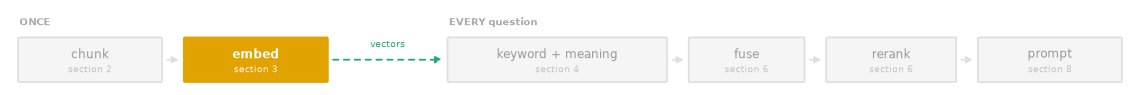

In [5]:
figures.locate("embed")

There are 324 passages now, and comparing a question against text has to become arithmetic
first. Classical text search represents a document as counts of the words in it, so the
coordinates are words you chose. An **embedding** model invents the
coordinates instead: a fixed-length list of numbers for any span of text, arranged so similar
meaning lands in a similar direction.

`all-MiniLM-L6-v2` is a small one: 6 layers, 22M parameters, about 90 MB. It is not a
language model. It emits one vector per passage rather than the next word, and was trained on
pairs of sentences that either do or do not mean the same thing. Underneath is a
**transformer**, where every token mixes in whatever other tokens are relevant to it, which
is how "reset" and "wipe" land near each other with no rule saying so. Same family as the
reranker in section 6 and as any LLM, differing in size and in what training rewarded.
`sentence-transformers` runs either, and supplies both here.

In [6]:
from transformers.utils import logging as hf_logging
from sentence_transformers import SentenceTransformer

# Loading the model prints a progress bar that freezes at 0% in a saved notebook.
# transformers ships with sentence-transformers, so this costs no extra dependency.
hf_logging.disable_progress_bar()

encoder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

def embed(texts):
    return encoder.encode(texts, normalize_embeddings=True, batch_size=64,
                          show_progress_bar=False)

E = embed([c["text"] for c in chunks])
print("E:", E.shape, "->", E.shape[0], "chunks x", E.shape[1], "numbers each")
print("every row has length 1:", np.allclose(np.linalg.norm(E, axis=1), 1.0))

E: (324, 384) -> 324 chunks x 384 numbers each
every row has length 1: True


*In production:* a hosted embedding API such as Voyage, OpenAI or Cohere, or a larger open
model like `bge` or `e5`. More dimensions usually means better matching and more storage.

That matrix is `E`, and every search here is something done to it. **Each row is one chunk.**
The 384 numbers inside a row mean nothing individually: there is no dimension for "database".
Direction carries the meaning, which is why everything below compares whole rows and never
looks inside one.

Every row is also scaled to length 1. For unit vectors the dot product *is* the cosine of
the angle between them, so comparing two chunks is one multiplication rather than a formula.

Below, one chunk is the reference and four others sit at the angle the model produced.

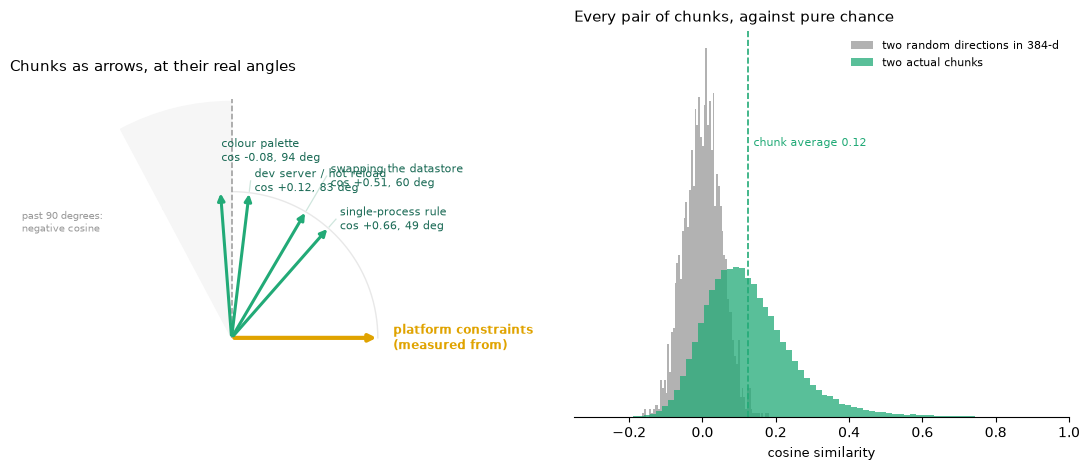

In [7]:
ref = next(k for k, c in enumerate(chunks) if "No persistent volumes" in c["text"])

others = {
    "single-process rule":     "assume a single process",
    "swapping the datastore":  "Swap the datastore",
    "dev server / hot reload": "hot module reload",
    "colour palette":          "Color Palette",
}
picked = {name: next(k for k, c in enumerate(chunks) if m in c["text"])
          for name, m in others.items()}

figures.cosine_fan("platform constraints", list(picked),
                   [float(E[ref] @ E[k]) for k in picked.values()], E)

The nearest passage sits 49 degrees away and is another set of platform constraints, from a
different file. The next one, at 60 degrees, is the same concern in an unrelated project,
and nobody told the model those two projects had anything in common. A dev-server passage
sits at 83, close to unrelated. A colour palette sits
just past 90 degrees, giving a small negative cosine. Negative means unrelated rather than
opposite: no pair of chunks here falls below -0.25.

The right-hand panel changes how to read every score here. Two random directions in 3
dimensions can be at any angle, but in 384 dimensions they are almost always near 90 degrees,
the grey pile at 0. Real chunks average 0.12 because they share a great deal before you reach
their topic: English, software, markdown, one person's habits.

So the 0.42 topping the search in section 4 is a strong match while sounding weak. Scores
mean something relative to other scores for the same question, which makes a fixed threshold
a shaky way to decide whether to answer.

## 4. Two ways to search

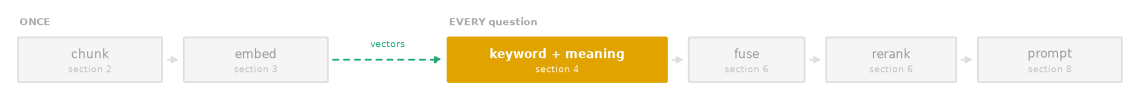

In [8]:
figures.locate("keyword + meaning")

With `E` built, searching by meaning is one line: score the question against every chunk
and keep the best few.

In [9]:
def search_by_meaning(query):
    q = embed([query])[0]
    return E @ q          # cosine against every chunk at once, because rows are unit length

def best(scores, k=5):
    return np.argsort(-scores)[:k]

demo = "why does the app avoid writing files to local disk?"
scores = search_by_meaning(demo)
for rank, i in enumerate(best(scores, 3), 1):
    flat = " ".join(chunks[i]["text"].split())
    print(f"{rank}. {scores[i]:.3f}  {chunks[i]['file']}")
    print(f"   {flat[:88]}...")

1. 0.423  secondhandplastic__CLAUDE.md
   - **No persistent volumes.** Anything written to local disk is lost on redeploy. State l...
2. 0.377  secondhandplastic__SECURITY.md
   written (`app/geo.py`). A report showing precise coordinates recoverable from the databa...
3. 0.345  secondhandplastic__README.md
   app/images.py upload validation, EXIF stripping, compression app/storage.py where proces...


*In production:* a vector database. `E @ q` is all the comparison there is; a store adds
persistence, metadata filters, and an index that finds approximately the nearest vectors
without scanning all of them, which starts to matter around a hundred million rows. If you
have used **pgvector**, `ORDER BY embedding <=> $1` is this same cosine, with the vectors
beside your relational data so scoping a search is a `WHERE` clause.

The other way to search is by keyword, and the standard is **BM25**. It scores a chunk by
the query words it literally contains, weighted by two ideas. **Term frequency**: a chunk
mentioning "postgres" five times beats one mentioning it once. **Inverse document
frequency**: a word appearing in every chunk tells you nothing, so "the" is worthless and a
rare token like a port number is valuable.

The formula comes from `rank_bm25`, a single-purpose package. The frequency table underneath
it is built here, because seeing real numbers is what makes the second idea concrete.

In [10]:
from rank_bm25 import BM25Okapi

def tokenize(s):
    return re.findall(r"[a-z0-9]+", s.lower())

def index_keywords(chunks):
    # Rebuilt whenever the chunking changes, since every count below depends on it.
    global docs, bm25
    docs = [tokenize(c["text"]) for c in chunks]
    bm25 = BM25Okapi(docs)
    return Counter(t for d in docs for t in set(d))   # chunks containing each word

df = index_keywords(chunks)

def search_by_keyword(query):
    return bm25.get_scores(tokenize(query))

for term in ["the", "database", "postgres", "5433"]:      # bm25.idf is the table it scores with
    print(f"{term:>10}  in {df[term]:>3} of {len(docs)} chunks   idf {bm25.idf[term]:.2f}")

       the  in 198 of 324 chunks   idf 1.18
  database  in  13 of 324 chunks   idf 3.14
  postgres  in  12 of 324 chunks   idf 3.22
      5433  in   2 of 324 chunks   idf 4.86


That table is the idea: a rare token is worth about four times a common one. `the` appears
in more than half the chunks, which scores below zero on the textbook formula. `rank_bm25`
floors that to a small positive number, so a common word cannot actively penalise the
chunks holding it. If you have used `TfidfVectorizer` from scikit-learn you have used
most of this already. What BM25 adds is saturation, so the twentieth "postgres" counts
barely more than the third, and a length penalty, so a long chunk cannot win by being big.

*In production:* Elasticsearch or OpenSearch, where BM25 usually lives at scale, or Postgres
full-text search. Postgres `ts_rank` is frequency-based rather than true BM25, and lexical
only, with no embeddings involved.

Those two searches produce vectors of different shapes, and the names are worth knowing
because papers and vector databases use them constantly. By meaning is **dense**: 384
numbers, almost none zero, coordinates the model invented. By keyword is **sparse**: one
coordinate per word in the vocabulary, nearly all zero, coordinates you can name.

Now the reason to care about both. Below, a star marks any chunk containing the string a
correct answer has to have.

In [11]:
def compare(query, marker, k=5):
    cols = [best(search_by_meaning(query), k), best(search_by_keyword(query), k)]
    tag = lambda i: f"{'*' if marker in chunks[i]['text'] else ' '} {chunks[i]['file'][:24]}#{i}"
    print(f"{query}\n{'':3}{'by meaning (dense)':<34}{'by keyword (sparse, BM25)':<34}")
    for r in range(k):
        print(f"{r+1:<3}" + "".join(tag(c[r]).ljust(34) for c in cols))

compare("how do I wipe my local database and start over?", "make reset")
print()
compare("what port does local Postgres listen on?", "5433")

how do I wipe my local database and start over?
   by meaning (dense)                by keyword (sparse, BM25)         
1  * secondhandplastic__CLAUD#221      mullet-stack__guide__ind#144    
2    whos-got-the-ball__READM#312      seanhelvey__README.md#203       
3    whos-got-the-ball__CLAUD#291      seanhelvey__README.md#208       
4    secondhandplastic__READM#250      whos-got-the-ball__READM#315    
5    secondhandplastic__CLAUD#225      whos-got-the-ball__READM#312    

what port does local Postgres listen on?
   by meaning (dense)                by keyword (sparse, BM25)         
1    whos-got-the-ball__READM#297      secondhandplastic__CLAUD#225    
2    whos-got-the-ball__READM#312    * secondhandplastic__CLAUD#219    
3    secondhandplastic__CLAUD#220      whos-got-the-ball__READM#297    
4    secondhandplastic__READM#268      secondhandplastic__READM#268    
5    secondhandplastic__CLAUD#225      secondhandplastic__READM#265    


They fail in opposite directions. The first needs `make reset`, which shares no words with
"wipe" or "start over", so keyword search never sees it. The second needs the exact token
`5433`, which keyword search puts second and the embedding never surfaces. Rare exact tokens
are the general case: error codes, customer IDs, part numbers, what people search for at
work.

## 5. Measuring retrieval

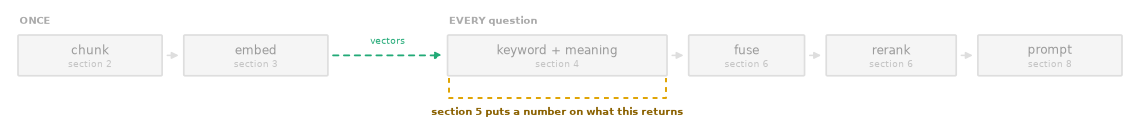

In [12]:
figures.locate(spans=(2, 2), note="section 5 puts a number on what this returns")

Everything above is a plausible story and none of it is evidence. Skipping this step is how a
RAG system fails quietly: confident answers, nothing thrown, nobody notices.

An eval works like a test suite: write down the right answer, then count how often you get
it. `queries.json` holds 18 questions, each with a **marker**: the exact string that has to
appear in a retrieved chunk for the search to count as correct.

```
q:      "how do I wipe my local database and start over?"
marker: "make reset"
```

Labelling is the expensive part, cheap here only because I wrote the corpus.

In [13]:
import json

queries = json.loads(pathlib.Path("queries.json").read_text())

def evaluate(retrieve, k=5):
    rr = []
    for item in queries:
        got = [chunks[i]["text"] for i in retrieve(item["q"], k)]
        ranks = [r for r, text in enumerate(got, 1) if item["marker"] in text]
        rr.append(1 / ranks[0] if ranks else 0.0)      # 0 when it never appeared at all
    return sum(r > 0 for r in rr) / len(rr), float(np.mean(rr))

results = {"by meaning": evaluate(lambda q, k: best(search_by_meaning(q), k)),
           "by keyword": evaluate(lambda q, k: best(search_by_keyword(q), k))}
for name, (r, m) in results.items():
    print(f"{name:<16} recall@5 {r:.2f}   MRR {m:.2f}")

by meaning       recall@5 0.78   MRR 0.61
by keyword       recall@5 0.72   MRR 0.53


**recall@5** is the fraction of questions whose answer appeared anywhere in the top 5.
**MRR** adds *how high*: 1 if the right chunk came first, 1/2 if second, 1/3 if third, 0 if
it never appeared, averaged over the questions.

Two numbers that close would normally mean "pick either". Ask *which* questions each one
misses and they do not.

In [14]:
for item in queries:
    hit = [any(item["marker"] in chunks[i]["text"] for i in best(fn(item["q"])))
           for fn in (search_by_meaning, search_by_keyword)]
    if hit[0] != hit[1]:
        print(f"{'meaning' if hit[0] else 'keyword':>7} only:  {item['q']}")

meaning only:  how do I wipe my local database and start over?
keyword only:  what port does local Postgres listen on?


meaning only:  what does it mean for someone to have the ball?
keyword only:  where do the TypeScript types stop lining up with the Python ones?
meaning only:  what colors does the site use?
keyword only:  where has the author worked for the past five years?
meaning only:  why keep JSON-LD if the guidance says not to?


They fail on almost disjoint sets, so neither is a strictly better ranker and running both
should beat either. That is a claim the next section has to prove rather than assert.

## 6. Fusing and reranking

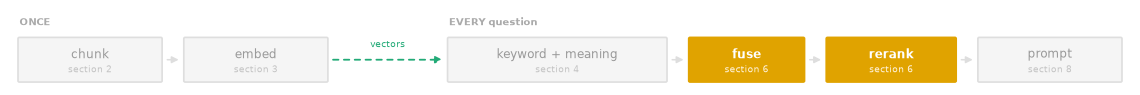

In [15]:
figures.locate(("fuse", "rerank"))

The eval said the two searches miss different questions, so running both should beat either.
Adding the score arrays together does not do it: one is a cosine in a small range, the other
an unbounded sum of logs. **Reciprocal rank fusion** sidesteps that by throwing the
scores away and using only positions. First place is first place, whatever number produced
it.

If you have combined weak models before, this is that idea, applied to ranked lists.

In [16]:
def rrf(rankings, k=5, damp=60):
    # Each list votes 1/(damp + rank) for what it put where. 60 is from the original paper
    # and flattens each list's top, so one confident-but-wrong ranker cannot run away with it.
    votes = Counter()
    for ranking in rankings:
        for rank, idx in enumerate(ranking):
            votes[idx] += 1 / (damp + rank)
    return [i for i, _ in votes.most_common(k)]

def hybrid(query, k=5, pool=25):
    return rrf([list(best(search_by_meaning(query), pool)),
                list(best(search_by_keyword(query), pool))], k=k)

# C is nobody's favourite but appears on both lists, so it beats B, which only one liked.
print(rrf([["A", "B", "C"], ["C", "A", "D"]], k=4))

['A', 'C', 'B', 'D']


*In production:* `EnsembleRetriever` in LangChain, or the hybrid mode most search engines
now ship.

In [17]:
results["both, fused"] = evaluate(hybrid)
print(f"both, fused      recall@5 {results['both, fused'][0]:.2f}   "
      f"MRR {results['both, fused'][1]:.2f}")

both, fused      recall@5 0.83   MRR 0.53


Recall went up and MRR went down, below what searching by meaning alone managed. Fusion is
good at dragging the right chunk into the top few and bad at knowing which of them is best.
Fixing the order needs a different kind of model.

Everything so far compares vectors computed separately, the chunks long before the question
arrived. That is what makes search fast, and it means a chunk's vector cannot depend on what
was asked. A **cross-encoder** puts the question and one chunk through the model together, so
it weighs them against each other directly. Much more accurate, far too slow for every
chunk.

Hence the usual arrangement: retrieve 25 candidates cheaply, rescore those carefully, keep
the best few. The reranker loads from `sentence-transformers` too.

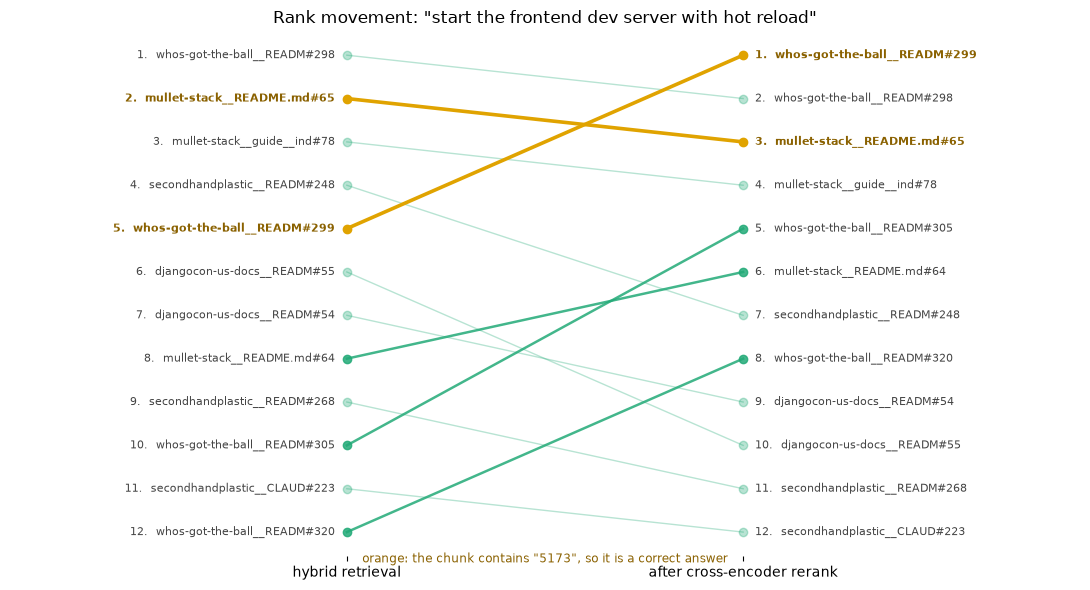

In [18]:
from sentence_transformers import CrossEncoder

reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

def rerank(query, idxs):
    scores = reranker.predict([(query, chunks[i]["text"]) for i in idxs])
    return [i for _, i in sorted(zip(scores, idxs), key=lambda p: -p[0])]

def hybrid_reranked(query, k=5, pool=25):
    return rerank(query, hybrid(query, k=pool, pool=pool))[:k]

q = "start the frontend dev server with hot reload"
before = hybrid(q, k=12, pool=12)
figures.rank_movement(q, before, rerank(q, before), chunks, marker="5173")

*In production:* Cohere Rerank, `bge-reranker-v2-m3`, or Voyage.

Orange marks the two chunks mentioning port 5173, which a correct answer needs. Fusion had
them at ranks 2 and 5, the reranker moved them to 1 and 3. Same candidates, better order,
and that matters because the prompt has room for about three chunks, not twenty-five.

by meaning       recall@5 0.78   MRR 0.61
by keyword       recall@5 0.72   MRR 0.53
both, fused      recall@5 0.83   MRR 0.53
fused + rerank   recall@5 0.94   MRR 0.78


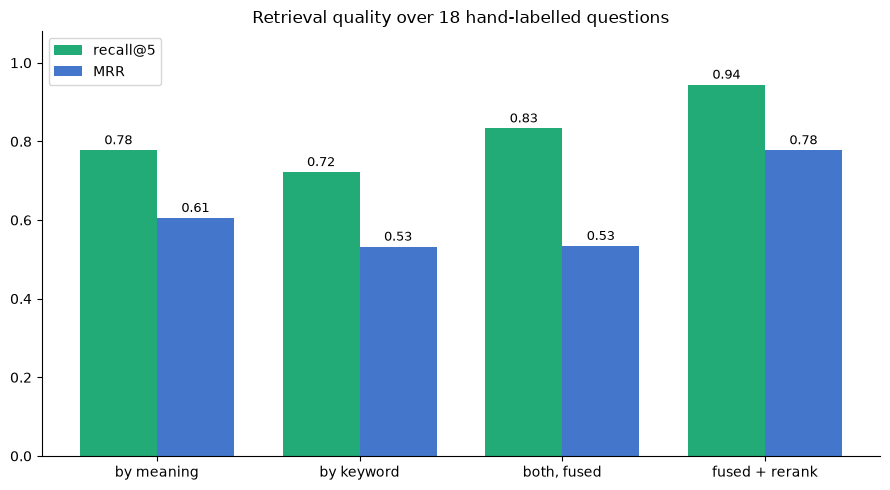

In [19]:
results["fused + rerank"] = evaluate(hybrid_reranked)
for name, (r, m) in results.items():
    print(f"{name:<16} recall@5 {r:.2f}   MRR {m:.2f}")
figures.retrieval_quality(results, len(queries))

Read the four bars as the argument in order. The two searches land close, 0.78 and 0.72, and
miss different questions, so fusion lifts recall to 0.83. Fusion leaves MRR at 0.53 because
it cannot tell first place from fifth. The reranker takes those same candidates and fixes
the order, 0.53 to 0.78, the largest single move in the chart.

## 7. What moves the numbers

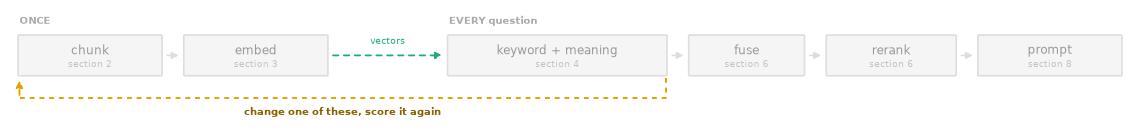

In [20]:
figures.locate(spans=(0, 2), loop=True, note="change one of these, score it again")

That is the retrieval stack finished: 0.78 to 0.94, four methods, each measured. What decides
the number more than any of them is a set of choices that are not models, and the eval is
what settles them instead of leaving them to opinion.

**Where you cut.** An eval earns its keep by catching a change that made things worse. Say
smaller chunks sound more precise, so the size drops from 400 characters to 150. Two numbers,
it runs without error, and every answer still looks plausible.

In [21]:
before = evaluate(hybrid)[0]

chunks = build_chunks(chunk_size=150, overlap=30)     # the "improvement"
E = embed([c["text"] for c in chunks])
index_keywords(chunks)
after = evaluate(hybrid)[0]

chunks = build_chunks()                              # put it back
E = embed([c["text"] for c in chunks])
index_keywords(chunks)

print(f"chunk size 400 -> recall@5 {before:.2f}    150 -> recall@5 {after:.2f}")
print(f"verdict: {'REGRESSION' if after < before else 'fine'}, "
      f"{(before-after)*len(queries):.0f} of {len(queries)} questions newly broken")

chunk size 400 -> recall@5 0.83    150 -> recall@5 0.61
verdict: REGRESSION, 4 of 18 questions newly broken


That is the argument for evals in one cell. Two caveats: with 18 questions each is worth
0.06 recall, so this can say "150 is a bad idea" but cannot referee 0.83 against 0.94. And it
measures retrieval only, the half you can check without a language model.

Below is what the windowing does to a long section.

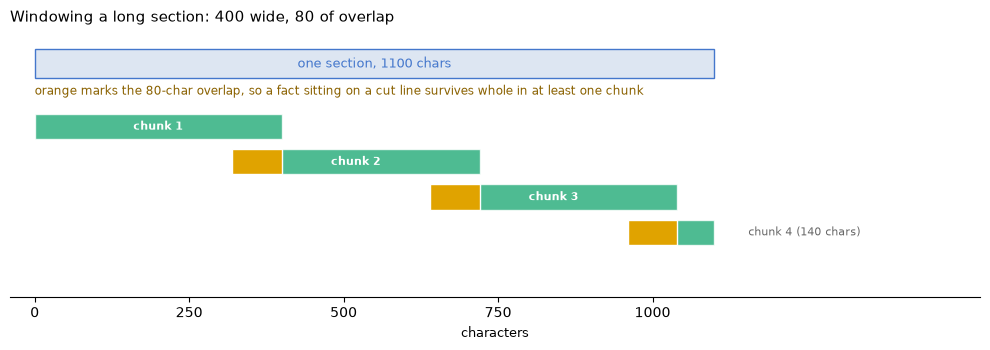

In [22]:
figures.chunk_windows(sec_len=1100, max_chars=400, overlap=80)

**Questions with no single answer.** Two unrelated projects here run a dev server on port
5173, so "start the frontend dev server" has several correct answers and no way to choose.
No reranker fixes that. Metadata filtering does: scope the search to one project, which is a
`WHERE` clause rather than a better model.

**Staleness.** The embeddings were computed once, and the moment anyone edits a document they
are out of date. Re-embedding everything is fast here and expensive on a real corpus, so
production systems re-embed only what changed. Each chunk needs a stable identity for that,
and hashing its text works.

In [23]:
import hashlib

def chunk_id(c):
    return hashlib.sha256(c["text"].encode()).hexdigest()[:12]

index = {chunk_id(c): c for c in chunks}      # what is already embedded

edited = build_chunks()                        # pretend one file just changed
edited[7] = {**edited[7], "text": edited[7]["text"] + " A sentence someone just added."}

fresh = [c for c in edited if chunk_id(c) not in index]
gone  = set(index) - {chunk_id(c) for c in edited}

print(f"{len(edited)} chunks, {len(fresh)} need embedding, {len(gone)} to delete")
print(f"{len(edited) - len(fresh)} of {len(edited)} embeddings reused")

324 chunks, 1 need embedding, 1 to delete
323 of 324 embeddings reused


One chunk changed, so one needs embedding and its old copy is dropped. A real edit shifts
the chunks after it too, and their hashes move with their text: identity comes from content
rather than position. Keyword search is rebuilt regardless, because document frequency is a
corpus-wide statistic.

The one that catches people: **changing the embedding model means re-embedding everything.**
Vectors from two models are not comparable, so there is no incremental path. A
half-migrated index returns nonsense rather than failing loudly, so store the model name
beside the vectors and the mismatch is at least detectable.

## 8. Generation, in one prompt

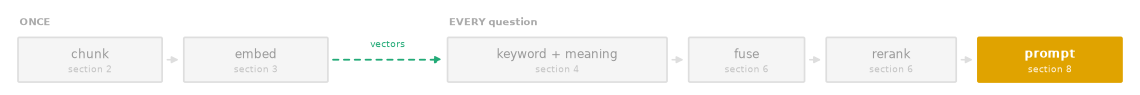

In [24]:
figures.locate("prompt")

The G, at last, and it is one request with the retrieved text in the prompt. No API call
here, which is partly the point: everything above was measured without a language model in
the loop.

In [25]:
question = "why is the rate limiter backed by the database instead of kept in memory?"
picked   = hybrid_reranked(question, k=3)

def build_prompt(trim=None):
    blocks = []
    for i in picked:
        text = chunks[i]["text"]
        text = " ".join(text.split())[:trim] + " ..." if trim else text   # fits on screen
        blocks.append(f"[source: {chunks[i]['file']}]\n{text}")
    return ("Answer the question using only the sources below.\n"
            "Cite the source filename for each claim.\n"
            "If the sources do not contain the answer, say so instead of guessing.\n\n"
            "SOURCES:\n" + "\n\n---\n\n".join(blocks) + f"\n\nQUESTION: {question}")

print(f"[{len(build_prompt())} characters. Below, the sources are cut short.]\n")
print(build_prompt(trim=140))

[1378 characters. Below, the sources are cut short.]

Answer the question using only the sources below.
Cite the source filename for each claim.
If the sources do not contain the answer, say so instead of guessing.

SOURCES:
[source: secondhandplastic__README.md]
Nothing may assume a single process. Most migrations must be additive-only, aside from the `post_deploy` exception above; the app does no sc ...

---

[source: secondhandplastic__CLAUDE.md]
in-memory, so limits are shared across instances and survive a restart; the app does no schema work at startup, so migrations run as a separ ...

---

[source: secondhandplastic__CLAUDE.md]
- **No persistent volumes.** Anything written to local disk is lost on redeploy. State lives in Supabase: Postgres for data, Storage for upl ...

QUESTION: why is the rate limiter backed by the database instead of kept in memory?


*In production:* one `client.messages.create` call with that string as the user message.

Each of those three instructions prevents a specific failure. **"Using only the sources"**
keeps the answer tied to what you retrieved, since otherwise the model answers from
pretraining and hides retrieval failures. **"Cite the filename"** makes claims checkable.
**"Say so instead of guessing"** gives the model an exit, because a confident wrong answer
is worse than "I don't know."

Good retrieval does not guarantee a good answer. The right chunk can be in the prompt and
the model still gets it wrong. RAG evaluation has a second half for that, called
**faithfulness**: is every claim in the answer supported by the retrieved text? Scoring
that needs a second model, so the tool for it, **RAGAS**, is named here rather than built.

## Where to go next

Five terms worth recognising, roughly in order of how much they would move the numbers here.

- **Contextual retrieval**: prefix each chunk with a sentence saying where it came from
  before embedding it, which fixes the chunk cut from the middle of a file that no longer
  makes sense alone.
- **Metadata filtering**: the `WHERE` clause from section 7.
- **Query rewriting**: expand the question before searching, so "how do I run this" gains
  some content words.
- **Late interaction (ColBERT)**: a vector per token rather than per chunk. Close to
  cross-encoder quality at closer to embedding speed.
- **Agentic retrieval**: hand the search to the model as a tool, let it read what came back
  and search again. This is where both frameworks now start, and it changes who decides when
  to stop rather than any of the machinery above. The retrieval inside the loop is this one.

**LangChain and LlamaIndex** are separate projects rather than layers, and production teams
often run a LlamaIndex retriever as a tool inside a LangChain loop. Either would replace most
of this notebook, which is the point of having read it first.

One last connection. **Attention**, the operation at the heart of a transformer, is also a
search: every word scores itself against every other and holds a blend of whatever was
relevant. RAG is the same shape over a store too large for the context window, with a hard
cut instead of a blend. Keep the top few, drop the rest.

## The short version

Almost none of the work is in the vector math. It is in cutting documents sensibly, running
keyword search alongside semantic search, and writing down enough labelled questions to
have a number to point at when someone proposes a change.